--- 1. INSPECCIÓN GENERAL ---


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

--- 2. LIMPIEZA BÁSICA ---
Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Tamaño después de limpiar nulos: (333, 7)

--- 3. ANÁLISIS UNIVARIADO (No Gráfico) ---


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


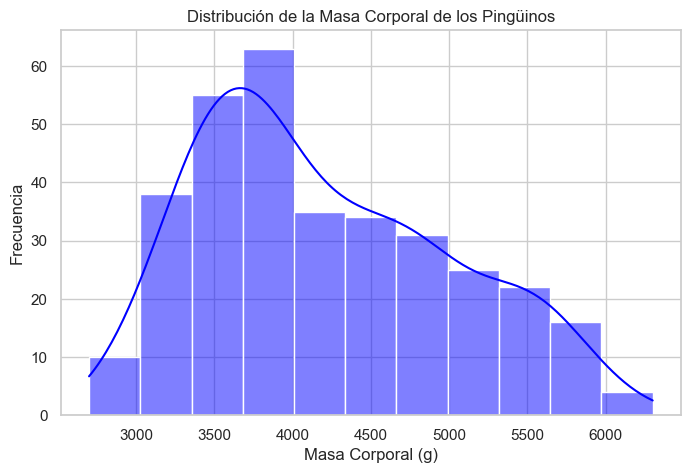

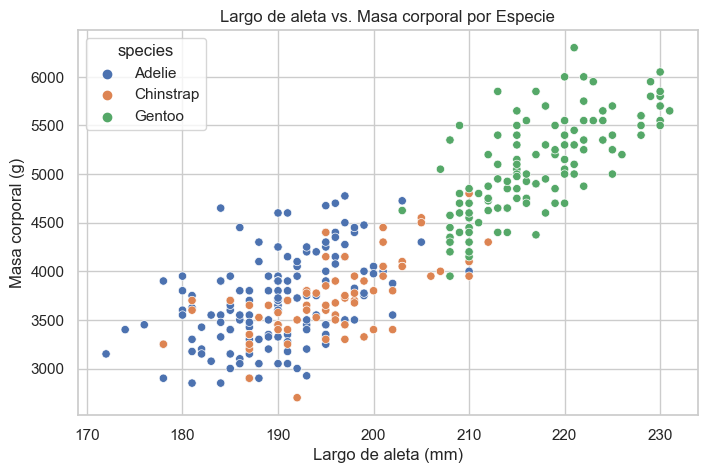

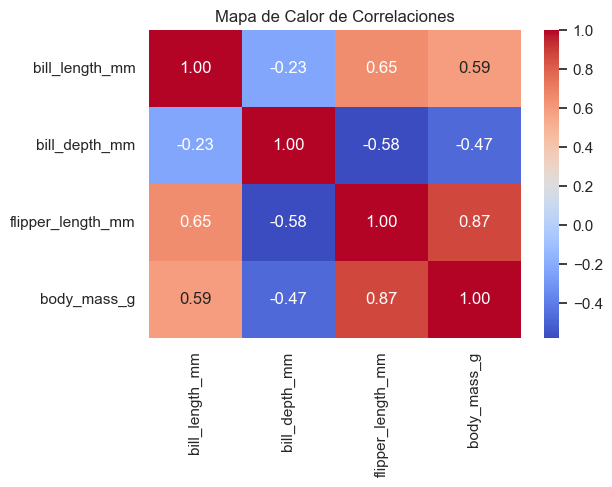

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS: dataset de ejemplo directamente desde seaborn
df = sns.load_dataset('penguins')

print("--- 1. INSPECCIÓN GENERAL ---")
# Mostrar las primeras filas y la información general
display(df.head())
print("\nInformación del Dataset:")
df.info()

print("\n--- 2. LIMPIEZA BÁSICA ---")
# Revisar cuántos valores nulos hay por columna
print("Valores nulos por columna:")
print(df.isnull().sum())
# Eliminamos las filas con valores nulos
df_limpio = df.dropna()
print(f"\nTamaño después de limpiar nulos: {df_limpio.shape}")

print("\n--- 3. ANÁLISIS UNIVARIADO (No Gráfico) ---")
# Estadísticas descriptivas de las variables numéricas
display(df_limpio.describe())

# --- 4. ANÁLISIS GRÁFICO (Univariado y Multivariado) ---
# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Gráfico 1: Univariado (Distribución del peso de los pingüinos)
plt.figure(figsize=(8, 5))
sns.histplot(df_limpio['body_mass_g'], kde=True, color='blue')
plt.title('Distribución de la Masa Corporal de los Pingüinos')
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico 2: Bivariado (Relación entre largo de aleta y peso, separado por especie)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_limpio, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Largo de aleta vs. Masa corporal por Especie')
plt.xlabel('Largo de aleta (mm)')
plt.ylabel('Masa corporal (g)')
plt.show()

# Gráfico 3: Multivariado (Matriz de correlación de variables numéricas)
plt.figure(figsize=(6, 4))
# Seleccionamos solo las columnas numéricas para la correlación
columnas_numericas = df_limpio.select_dtypes(include=['float64', 'int64'])
matriz_correlacion = columnas_numericas.corr()

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()